# exp09 generation & fusion (upscaled centered dataset)

Load the weights of `exp09_stage1_pokemonALLcentered_xattn48`, do by-name / free-text generation + fusion. Same architecture as exp08 (cross-attn @48).


## Model + diffusion (consistent with training)


In [1]:
import math, os, glob, json, random
import torch
import torch.nn as nn
import torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"

# time embedding: turn the integer t "which denoising step we're on" into a vector (similar to Transformer positional encoding),
# Let the network know "how much noise there currently is". Done by concatenating a set of sin/cos at different frequencies into a vector.
def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / half)  # a set of frequencies from high to low
    args = t[:, None].float() * freqs[None, :]                                                  # each frequency multiplied by step t
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)                                # concat sin and cos into the final vector

In [2]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, c_dim, groups=8):
        super().__init__()
        # main path first segment: normalize -> activation -> 3x3 conv (can change channels here in_ch -> out_ch)
        self.block1 = nn.Sequential(nn.GroupNorm(groups, in_ch), nn.SiLU(), nn.Conv2d(in_ch, out_ch, 3, padding=1))
        # project the condition vector c (time+text) to out_ch dims, then add it to the feature map
        self.cond_mlp = nn.Sequential(nn.SiLU(), nn.Linear(c_dim, out_ch))
        # main path second segment
        self.block2 = nn.Sequential(nn.GroupNorm(groups, out_ch), nn.SiLU(), nn.Conv2d(out_ch, out_ch, 3, padding=1))
        # shortcut (residual): pass through as-is if channels unchanged (Identity), use 1x1 conv to match if channels change, so they can be added at the end
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, c):
        h = self.block1(x)                          # main path first segment
        h = h + self.cond_mlp(c)[:, :, None, None]  # broadcast-add condition c to every pixel (inject "which step + what to draw")
        h = self.block2(h)                          # main path second segment
        return h + self.skip(x)                     # residual: F(x) + shortcut(x)

In [3]:
class SelfAttn(nn.Module):
    """pixel <-> pixel self-attention (global coherence). O(N^2), expensive, only used at low resolution."""
    def __init__(self, ch, heads=4):
        super().__init__(); self.norm = nn.GroupNorm(8, ch); self.mha = nn.MultiheadAttention(ch, heads, batch_first=True)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).reshape(B, C, H*W).transpose(1, 2)   # flatten the image into a sequence (B, num_pixels, channels): each pixel is a token
        h, _ = self.mha(h, h, h)                              # q=k=v are all itself -> pixels "look at" each other
        return x + h.transpose(1, 2).reshape(B, C, H, W)      # add residual back and restore the image shape

In [4]:
class CrossAttn(nn.Module):
    """pixel <-> text token cross-attention (spatialized text control). O(pixels*words), cheap, can be used at higher resolution."""
    def __init__(self, ch, ctx_dim=512, heads=4):
        super().__init__(); self.norm = nn.GroupNorm(8, ch); self.kv = nn.Linear(ctx_dim, ch)  # project text features to the image channel count
        self.mha = nn.MultiheadAttention(ch, heads, batch_first=True)
    def forward(self, x, ctx, key_padding_mask=None):
        B, C, H, W = x.shape
        q = self.norm(x).reshape(B, C, H*W).transpose(1, 2)           # query = image pixels
        kv = self.kv(ctx)                                            # key/value = per-word text features (ctx is the CLIP token sequence)
        h, _ = self.mha(q, kv, kv, key_padding_mask=key_padding_mask)  # each pixel "reads" every word; mask blocks padding words
        return x + h.transpose(1, 2).reshape(B, C, H, W)              # add residual back

In [5]:
class Stage(nn.Module):
    """n_blocks ResBlocks + independently toggleable self-attn / cross-attn."""
    def __init__(self, in_ch, out_ch, c_dim, n_blocks=2, self_attn=False, cross_attn=False):
        super().__init__()
        # the first ResBlock changes channels (in->out), the rest keep out->out
        self.blocks = nn.ModuleList([ResBlock(in_ch if i==0 else out_ch, out_ch, c_dim) for i in range(n_blocks)])
        self.self_attn  = SelfAttn(out_ch)  if self_attn  else None   # enable self-attention on demand
        self.cross_attn = CrossAttn(out_ch) if cross_attn else None   # enable cross-attention on demand
    def forward(self, x, c, ctx=None, mask=None):
        for b in self.blocks: x = b(x, c)                             # first pass through several ResBlocks (all injected with condition c)
        if self.self_attn  is not None: x = self.self_attn(x)         # then (optionally) do self-attention
        if self.cross_attn is not None: x = self.cross_attn(x, ctx, mask)  # then (optionally) do cross-attention (read the text)
        return x

In [6]:
class UNet(nn.Module):
    """exp08: cross-attn added at 48 (down2/up2 cross only); 24/12 still self+cross."""
    def __init__(self, in_ch=3, base=128, c_dim=256, n_blocks=2, txt_dim=512):
        super().__init__(); self.c_dim = c_dim
        self.text_proj = nn.Sequential(nn.Linear(txt_dim, c_dim), nn.SiLU(), nn.Linear(c_dim, c_dim))  # pooled text -> condition dim
        self.time_mlp  = nn.Sequential(nn.Linear(c_dim, c_dim), nn.SiLU(), nn.Linear(c_dim, c_dim))    # time vector -> condition dim
        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1)   # entry: 3 channels -> base channels
        # encoder: channels double at each level down (AvgPool halves the size, see forward)
        self.down1 = Stage(base,    base,   c_dim, n_blocks)                                      # 96^2
        self.down2 = Stage(base,    base*2, c_dim, n_blocks, cross_attn=True)                     # 48^2: cross only
        self.down3 = Stage(base*2,  base*4, c_dim, n_blocks, self_attn=True, cross_attn=True)     # 24^2: self+cross
        self.downsample = nn.AvgPool2d(2)                     # average pooling downsample, halves the size (no parameters)
        self.mid = Stage(base*4, base*4, c_dim, n_blocks, self_attn=True, cross_attn=True)        # 12^2 bottleneck
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")  # nearest-neighbor upsample, doubles the size
        # decoder: input channels = upsampled + skip connection (so it's the sum of two parts)
        self.up3 = Stage(base*4+base*4, base*2, c_dim, n_blocks, self_attn=True, cross_attn=True) # 24^2
        self.up2 = Stage(base*2+base*2, base,   c_dim, n_blocks, cross_attn=True)                 # 48^2: cross only
        self.up1 = Stage(base+base,     base,   c_dim, n_blocks)                                  # 96^2
        self.out = nn.Sequential(nn.GroupNorm(8, base), nn.SiLU(), nn.Conv2d(base, in_ch, 3, padding=1))  # exit -> 3 channels (predicted noise)
    def forward(self, x, t, pooled, tokens, mask):
        c = self.time_mlp(sinusoidal_embedding(t, self.c_dim)) + self.text_proj(pooled)  # global condition c = time + pooled text
        x = self.in_conv(x)
        s1 = self.down1(x, c);                  x = self.downsample(s1)   # save s1 for the skip connection, then downsample
        s2 = self.down2(x, c, tokens, mask);    x = self.downsample(s2)   # cross @48
        s3 = self.down3(x, c, tokens, mask);    x = self.downsample(s3)   # @24
        x = self.mid(x, c, tokens, mask)                                  # @12 bottleneck
        x = self.upsample(x); x = self.up3(torch.cat([x, s3], 1), c, tokens, mask)  # after upsampling, concat skip connection s3, then pass through Stage
        x = self.upsample(x); x = self.up2(torch.cat([x, s2], 1), c, tokens, mask)  # cross @48
        x = self.upsample(x); x = self.up1(torch.cat([x, s1], 1), c)
        return self.out(x)                                               # output the predicted noise epsilon

In [7]:
class Diffusion:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = timesteps; self.device = device
        beta = torch.linspace(beta_start, beta_end, timesteps, device=device)  # how much noise to add at each step (variance schedule, linearly increasing)
        self.beta = beta; self.alpha = 1.0 - beta; self.alpha_bar = torch.cumprod(self.alpha, 0)  # alpha_bar = cumulative product of alpha
    def q_sample(self, x0, t, noise):
        # forward noising: compute the noisy image at step t in one shot = sqrt(ab)*original + sqrt(1-ab)*noise
        ab = self.alpha_bar[t][:, None, None, None]; return ab.sqrt()*x0 + (1-ab).sqrt()*noise
    def loss(self, model, x0, pooled, tokens, mask):
        B = x0.size(0); t = torch.randint(0, self.T, (B,), device=x0.device); noise = torch.randn_like(x0)  # random step + random noise
        # let the network look at the noisy image and predict the "added noise", loss = MSE between predicted noise and true noise
        return F.mse_loss(model(self.q_sample(x0, t, noise), t, pooled, tokens, mask), noise)
    @torch.no_grad()
    def sample(self, model, n, pooled, tokens, mask, null, guidance=4.0, img_size=96):
        """pooled(n,512) tokens(n,L,512) mask(n,L); null=(p,t,m) single entry, expanded to n internally."""
        model.eval()
        np_, nt_, nm_ = null
        np_ = np_[None].expand(n, -1); nt_ = nt_[None].expand(n, -1, -1); nm_ = nm_[None].expand(n, -1)  # replicate the null condition into n copies
        x = torch.randn(n, 3, img_size, img_size, device=self.device)  # start from pure noise
        for i in reversed(range(self.T)):                              # denoise backwards from step T-1 to step 0
            t = torch.full((n,), i, device=self.device, dtype=torch.long)
            ec = model(x, t, pooled, tokens, mask)             # conditional prediction (sees the prompt)
            eu = model(x, t, np_, nt_, nm_)                    # unconditional prediction (sees empty prompt)
            pred = eu + guidance * (ec - eu)                   # CFG: amplify the result toward the prompt direction
            bt, at, abt = self.beta[i], self.alpha[i], self.alpha_bar[i]
            mean = (1/at.sqrt()) * (x - (bt/(1-abt).sqrt()) * pred)       # use predicted noise to back out the denoised mean for this step
            x = mean + (bt.sqrt()*torch.randn_like(x) if i > 0 else 0.0)  # add a bit of random noise (none on the last step)
        model.train(); return x

## Load CLIP (per-token) + exp09 weights


In [8]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
try:
    import open_clip
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable,"-m","pip","install","-q","open_clip_torch"]); import open_clip
_clip,_,_ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
_tok = open_clip.get_tokenizer("ViT-B-32"); _clip = _clip.to(device).eval()

@torch.no_grad()
def clip_seq(text):
    """One sentence of text -> (pooled(1,512), tokens(1,77,512), mask(1,77))"""
    t = _tok([text]).to(device)
    x = _clip.token_embedding(t) + _clip.positional_embedding
    x = _clip.transformer(x, attn_mask=_clip.attn_mask); x = _clip.ln_final(x)
    p = x[torch.arange(1), t.argmax(-1)] @ _clip.text_projection; p = p/p.norm(dim=-1,keepdim=True)
    return p.float(), x.float(), (t == 0)

EXP_NAME = "exp09_stage1_pokemonALLcentered_xattn48"        # ← change to your experiment
OUT_DIR  = os.path.join("/root/autodl-tmp/experiments", EXP_NAME)
CKPT     = os.path.join(OUT_DIR, "checkpoints", "ckpt_ep300.pt")   # ← change epoch
names = json.load(open(os.path.join(OUT_DIR,"classes.json"), encoding="utf-8"))
descs = json.load(open("/root/autodl-tmp/descriptions.json", encoding="utf-8"))
model = UNet(base=128, n_blocks=2).to(device)
model.load_state_dict(torch.load(CKPT, map_location=device)); model.eval()
diff = Diffusion(timesteps=1000, device=device)
null = clip_seq("")
null = (null[0][0], null[1][0], null[2][0])         # single item
print("loaded:", EXP_NAME, "| classes", len(names))

def show(imgs, title=""):
    g = make_grid(((imgs.clamp(-1,1)+1)/2).cpu(), nrow=min(len(imgs),4)).permute(1,2,0).numpy()
    plt.figure(figsize=(8,8)); plt.imshow(g); plt.axis("off"); plt.title(title); plt.show()

已加载: exp09_stage1_pokemonALLcentered_xattn48 | 类别 988


## 1. Generate by name / free text
Using a Pokémon's training description `descs["pikachu"]` is most stable; you can also write any sentence.


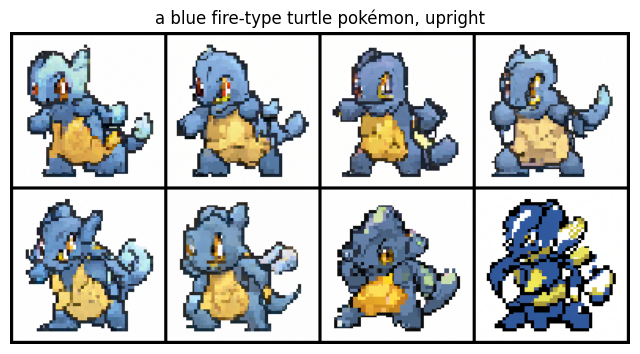

In [9]:
# Free text: just write a description (anything)
PROMPT = "a blue fire-type turtle pokémon, upright body"
# want to exactly reproduce a specific Pokémon? use its training description ->  PROMPT = descs["pikachu"]
N = 8; GUIDANCE = 4.0
p, tok, m = clip_seq(PROMPT)
imgs = diff.sample(model, N, p.expand(N,-1), tok.expand(N,-1,-1), m.expand(N,-1), null, guidance=GUIDANCE, img_size=96)
show(imgs, PROMPT[:40])

## 2. Fusion (cross-attn token concatenation)
Concatenate the tokens of descriptions A and B, so the image cross-attends to both word sets at once. If it gets washed-out/blurry, drop GUIDANCE to 2~3.


/root/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25340 (\N{CJK UNIFIED IDEOGRAPH-62FC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


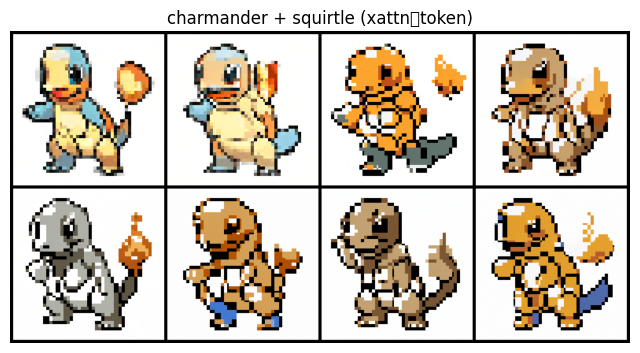

In [10]:
NAME_A = "charmander"; NAME_B = "squirtle"; N = 8; GUIDANCE = 4.0
pa, ta, ma = clip_seq(descs[NAME_A]); pb, tb, mb = clip_seq(descs[NAME_B])
tok = torch.cat([ta, tb], dim=1)               # concat tokens (1, 154, 512)
m   = torch.cat([ma, mb], dim=1)
p   = (pa + pb) / 2; p = p / p.norm(dim=-1, keepdim=True)
imgs = diff.sample(model, N, p.expand(N,-1), tok.expand(N,-1,-1), m.expand(N,-1), null, guidance=GUIDANCE, img_size=96)
show(imgs, f"{NAME_A} + {NAME_B} (xattn token concat)")

## Notes
- ckpt defaults to `ckpt_ep300.pt`; to see earlier results, change the epoch in the loading cell.
- There is a checkpoint every 10 epochs, so even if training has not finished you can use an intermediate checkpoint to generate.
